Computing ECC and sigma for 50-kernel sample...
Pearson r (sigma vs L2 to VP): -0.1857

  Kernel      sigma     L2 to VP    Wasserstein
--------------------------------------------------
    3934   0.215384      20.0250         4.9991
    2605   0.014621      20.2731         6.0454
    1288   0.375143      23.0000         3.8457
     634   0.001671      23.3666         0.8512
    1990   0.022942      23.4521         2.9281
    3843   0.028694      23.7065        10.9511
    2785   0.007990      23.8118         2.5661
    2631   0.115925      24.8797         9.1612
    1119   0.226919      25.3377         6.2907
    3455   0.420449      26.7021        10.8501


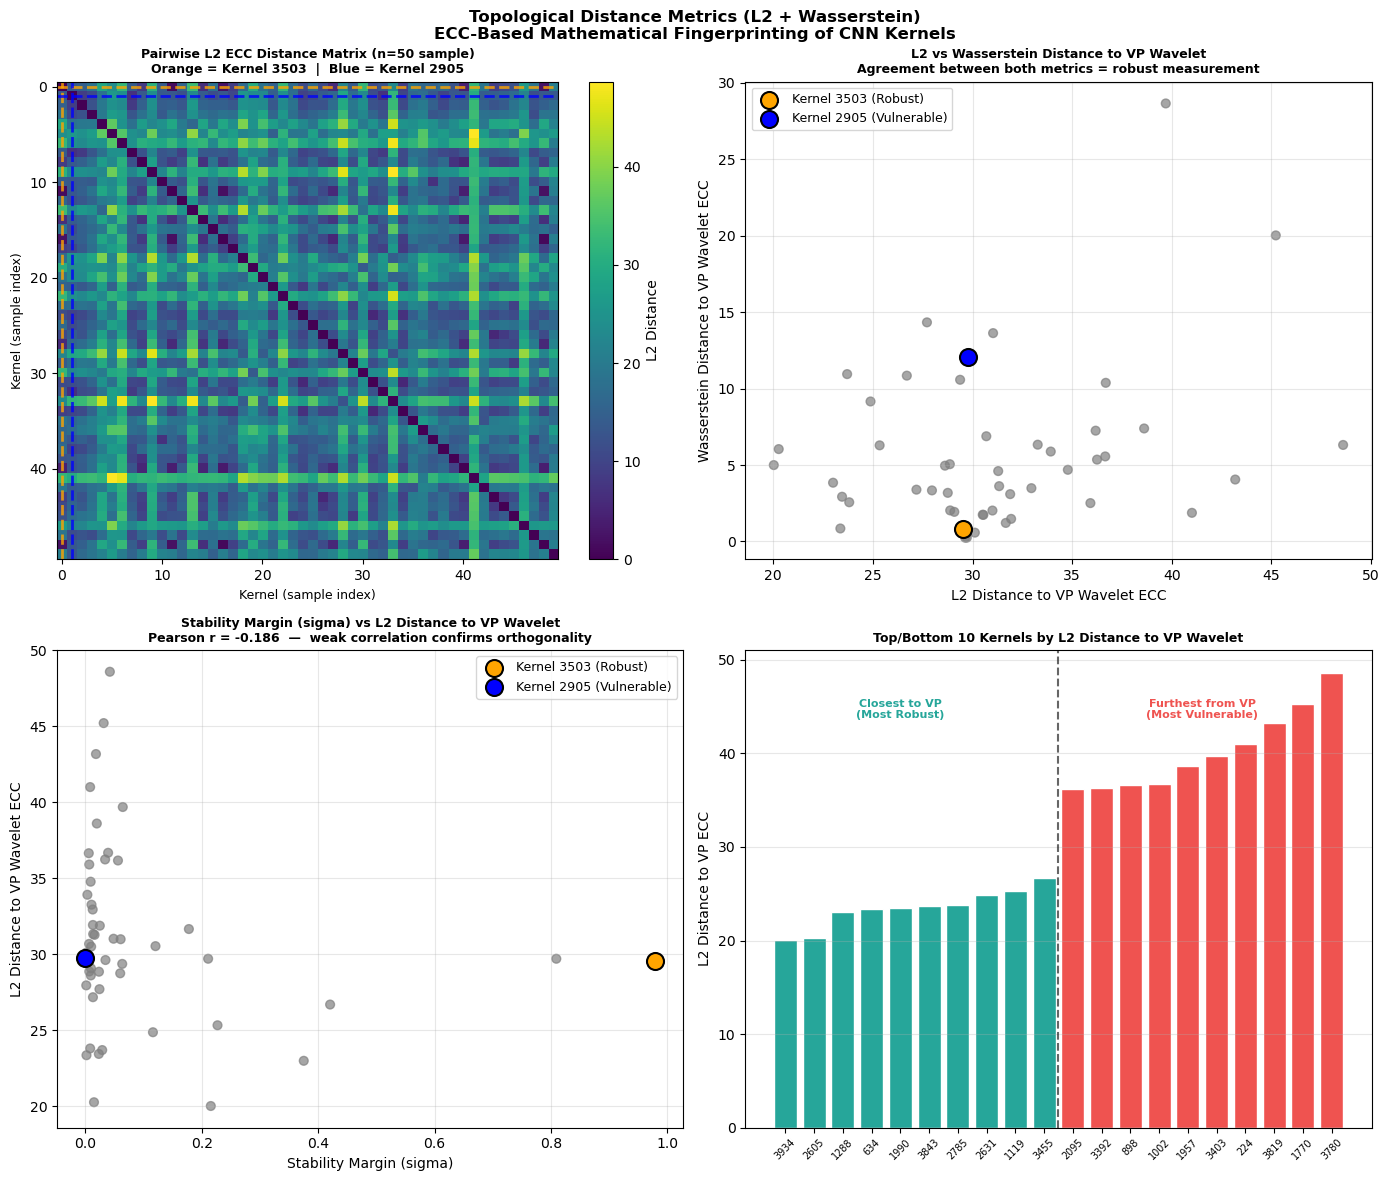

Saved: TopologicalDistanceMetrics.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              calculateEcc, eccL2Distance, eccWassersteinDistance,
                              generateVPWaveletKernel,
                              IDXROBUST, IDXVULNERABLE, GRIDSIZE, NTHRESH, CSVPATH)

# ============================================================
# Load kernels
# ============================================================
kernels = loadKernels(CSVPATH)

# ============================================================
# VP Wavelet reference (topological only)
# ============================================================
vp = generateVPWaveletKernel()
magVp = computeMagnitudeResponse(vp)
_, eccVp = calculateEcc(magVp)

# ============================================================
# Sample 50 kernels including both extremal kernels
# ============================================================
np.random.seed(0)
randomIndices = np.random.choice(
    [i for i in range(len(kernels)) if i not in [IDXROBUST, IDXVULNERABLE]],
    size=48, replace=False)
allIndices = np.array([IDXROBUST, IDXVULNERABLE] + list(randomIndices))

# ============================================================
# Compute ECC, sigma, and distances for sample
# ============================================================
print("Computing ECC and sigma for 50-kernel sample...")
eccs   = []
sigmas = []
for i, idx in enumerate(allIndices):
    h = kernels[idx]
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    eccs.append(ecc)
    sigmas.append(computeSigma(h))
eccs   = np.array(eccs)
sigmas = np.array(sigmas)

l2toVp    = np.array([eccL2Distance(e, eccVp) for e in eccs])
wasstoVp  = np.array([eccWassersteinDistance(e, eccVp) for e in eccs])
distMatrix = cdist(eccs, eccs, metric='euclidean')
corr = np.corrcoef(sigmas, l2toVp)[0, 1]

print(f"Pearson r (sigma vs L2 to VP): {corr:.4f}")

# ============================================================
# Print summary table
# ============================================================
print(f"\n{'Kernel':>8} {'sigma':>10} {'L2 to VP':>12} {'Wasserstein':>14}")
print("-" * 50)
for i in np.argsort(l2toVp)[:10]:
    k   = allIndices[i]
    tag = f" <- Kernel {IDXROBUST} (Robust)"     if k == IDXROBUST     else \
          f" <- Kernel {IDXVULNERABLE} (Vulnerable)" if k == IDXVULNERABLE else ""
    print(f"{k:>8} {sigmas[i]:>10.6f} {l2toVp[i]:>12.4f} {wasstoVp[i]:>14.4f}{tag}")

# ============================================================
# Figure
# ============================================================
scatterColors = ['orange' if idx == IDXROBUST else
                 'blue'   if idx == IDXVULNERABLE else
                 'gray'   for idx in allIndices]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Topological Distance Metrics (L2 + Wasserstein)\n"
             "ECC-Based Mathematical Fingerprinting of CNN Kernels",
             fontsize=12, fontweight='bold')

# Top left: pairwise distance matrix
ax = axes[0, 0]
im = ax.imshow(distMatrix, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='L2 Distance')
ax.axhline(0, color='orange', linewidth=2, linestyle='--', alpha=0.8)
ax.axvline(0, color='orange', linewidth=2, linestyle='--', alpha=0.8)
ax.axhline(1, color='blue',   linewidth=2, linestyle='--', alpha=0.8)
ax.axvline(1, color='blue',   linewidth=2, linestyle='--', alpha=0.8)
ax.set_title(f"Pairwise L2 ECC Distance Matrix (n=50 sample)\n"
             f"Orange = Kernel {IDXROBUST}  |  Blue = Kernel {IDXVULNERABLE}",
             fontsize=9, fontweight='bold')
ax.set_xlabel("Kernel (sample index)", fontsize=9)
ax.set_ylabel("Kernel (sample index)", fontsize=9)

# Top right: L2 vs Wasserstein
ax = axes[0, 1]
ax.scatter(l2toVp, wasstoVp, c=scatterColors, alpha=0.7, s=40)
ax.scatter(l2toVp[0], wasstoVp[0], c='orange', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXROBUST} (Robust)')
ax.scatter(l2toVp[1], wasstoVp[1], c='blue', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable)')
ax.set_title("L2 vs Wasserstein Distance to VP Wavelet\n"
             "Agreement between both metrics = robust measurement",
             fontsize=9, fontweight='bold')
ax.set_xlabel("L2 Distance to VP Wavelet ECC", fontsize=10)
ax.set_ylabel("Wasserstein Distance to VP Wavelet ECC", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom left: sigma vs L2
ax = axes[1, 0]
ax.scatter(sigmas, l2toVp, c=scatterColors, alpha=0.7, s=40)
ax.scatter(sigmas[0], l2toVp[0], c='orange', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXROBUST} (Robust)')
ax.scatter(sigmas[1], l2toVp[1], c='blue', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable)')
ax.set_title(f"Stability Margin (sigma) vs L2 Distance to VP Wavelet\n"
             f"Pearson r = {corr:.3f}  —  weak correlation confirms orthogonality",
             fontsize=9, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("L2 Distance to VP Wavelet ECC", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom right: top/bottom 10 by L2
ax = axes[1, 1]
order = np.argsort(l2toVp)
top10 = order[:10]
bot10 = order[-10:]
show  = np.concatenate([top10, bot10])
barColors = ['orange' if allIndices[i] == IDXROBUST else
             'blue'   if allIndices[i] == IDXVULNERABLE else
             '#26a69a' if i in top10 else '#ef5350'
             for i in show]
ax.bar(range(len(show)), l2toVp[show], color=barColors, edgecolor='white')
ax.axvline(9.5, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
ymax = max(l2toVp[show])
ax.text(4,    ymax*0.9, 'Closest to VP\n(Most Robust)',
        ha='center', fontsize=8, color='#26a69a', fontweight='bold')
ax.text(14.5, ymax*0.9, 'Furthest from VP\n(Most Vulnerable)',
        ha='center', fontsize=8, color='#ef5350', fontweight='bold')
ax.set_xticks(range(len(show)))
ax.set_xticklabels([str(allIndices[i]) for i in show], rotation=45, fontsize=7)
ax.set_title("Top/Bottom 10 Kernels by L2 Distance to VP Wavelet",
             fontsize=9, fontweight='bold')
ax.set_ylabel("L2 Distance to VP ECC", fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("TopologicalDistanceMetrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: TopologicalDistanceMetrics.png")